# Model Analysis

This notebook focuses on:
- Feature importance analysis
- Understanding the influence of features on model predictions using the SHAP library
- Analysis of instances where the model makes incorrect predictions

The previous notebook related to modeling can be found here: https://github.com/Maxstef/ml-bank-additional-project/blob/main/notebooks/03_modeling.ipynb


## Notebook initialization

In [1]:
# Notebook initialization
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

ROOT = Path.cwd()

while not (ROOT / "src").exists():
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

# print("Project root:", ROOT)

## Imports & Load Data

This analysis includes:
- The two best-performing models based on F1 score from the modeling stage: XGBoost and Random Forest
- A non–tree-based model (Logistic Regression) to provide a comparison with the top-performing tree-based models

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

import joblib
from src.config import MODELS_DIR
from src.data import load_raw_data

pipeline_xgb = joblib.load(MODELS_DIR / "xgb_model_pipeline.joblib")
pipeline_rforest = joblib.load(MODELS_DIR / "random_forest_model_pipeline.joblib")
pipeline_logreg = joblib.load(MODELS_DIR / "log_reg_model_pipeline.joblib")

raw_df = load_raw_data()
raw_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Split Data Train & Validation

In [3]:
from src.data import split_train_val, split_X_y

target_col = "y"

train_df, val_df = split_train_val(raw_df, stratify_col=target_col)

X_train, X_val, y_train, y_val = split_X_y(train_df, val_df, target_col)

X_train.shape, X_val.shape, y_train.shape, y_val.shape

((32950, 20), (8238, 20), (32950,), (8238,))

## Models Feature Importance

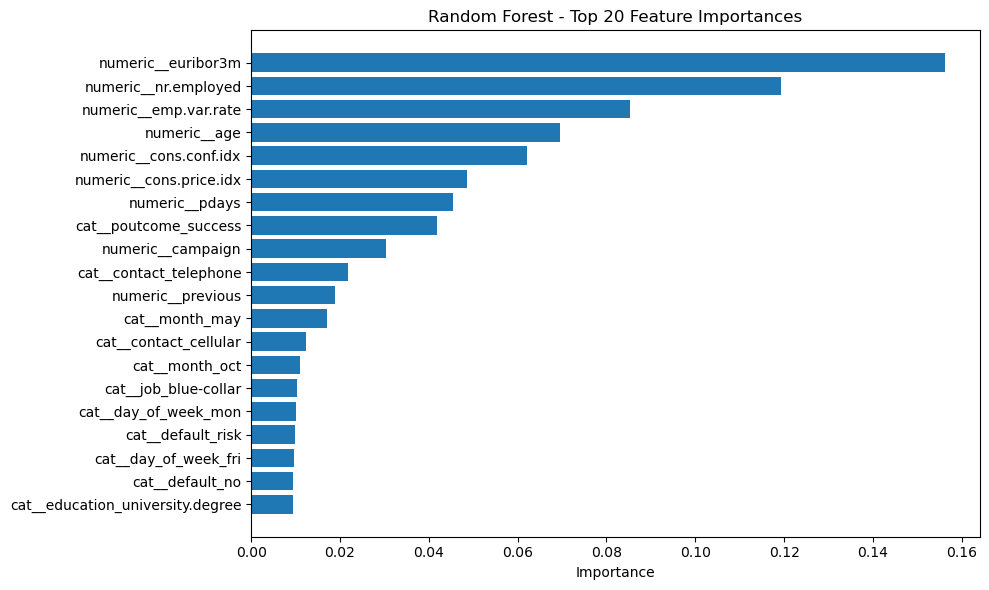

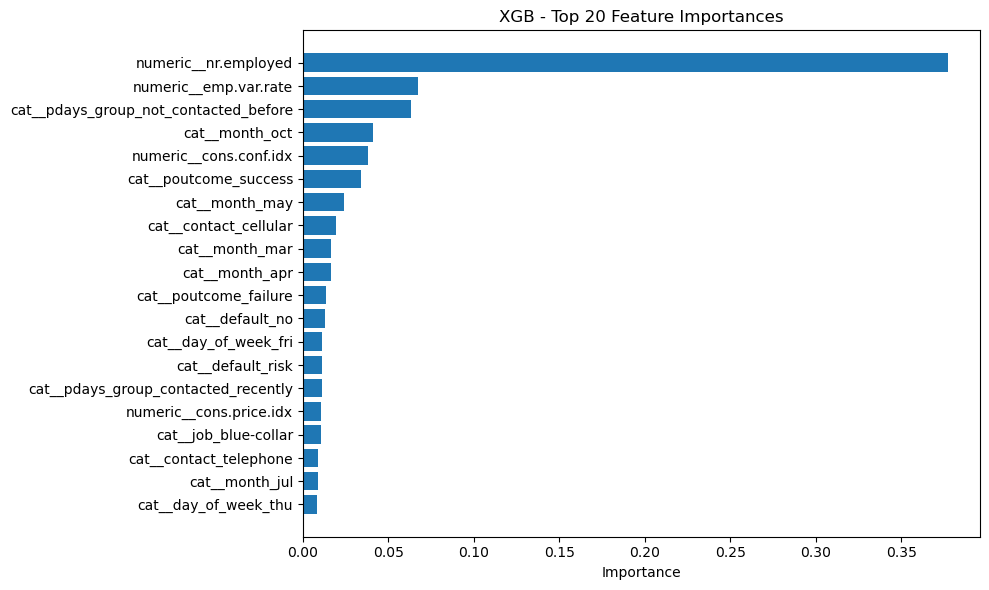

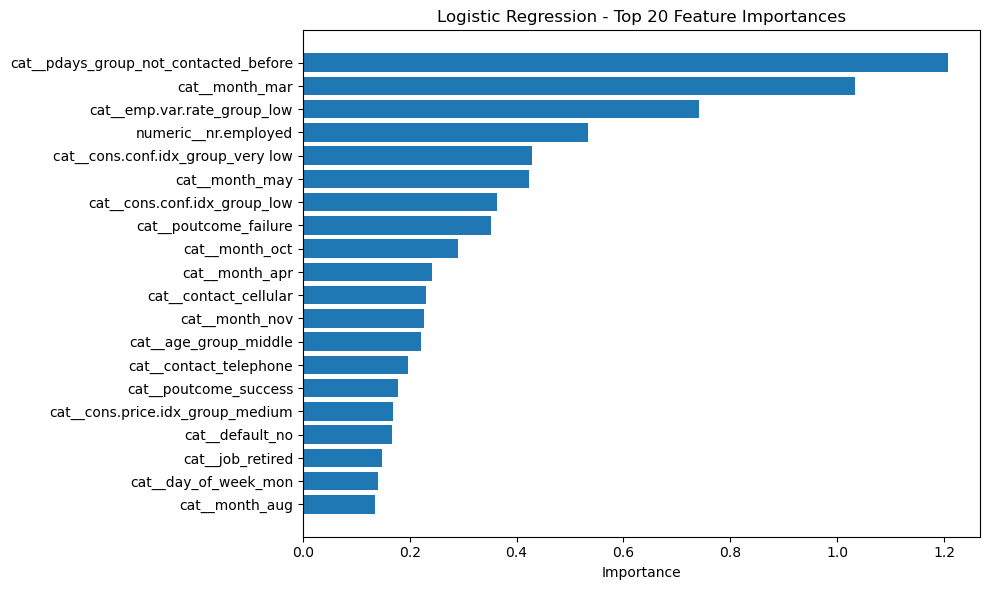

In [6]:
from src.visualizations import plot_feature_importance

plot_feature_importance(pipeline_rforest, top_n=20, name="Random Forest")
plot_feature_importance(pipeline_xgb, top_n=20, name="XGB")
plot_feature_importance(pipeline_logreg, top_n=20, name="Logistic Regression")

### Feature Importance Analysis

The feature importance results across XGBoost, Random Forest, and Logistic Regression show several consistent patterns.

**Key Predictive Drivers**  
- Macroeconomic indicators such as `nr.employed`, `emp.var.rate`, and `cons.conf.idx` are among the most influential features, highlighting the strong impact of broader economic conditions.

**Customer History and Campaign Effects**  
- Features like `pdays`, `poutcome_success`, `poutcome_failure`, and `campaign` are consistently important, indicating that prior interactions and campaign outcomes are key predictors.

**Temporal Patterns**  
- Month-related features (e.g., `month_mar`, `month_may`, `month_oct`) appear across models, suggesting seasonal effects in campaign performance.

**Contact and Demographic Features**  
- Contact type and customer attributes (e.g., job and default-related features) contribute to predictions, reflecting differences across customer segments.

**Model-Specific Observations**  
- Tree-based models capture non-linear relationships using both numerical and categorical features.  
- Logistic Regression relies more on engineered group features, reflecting linear relationships and clearer feature effects.

**Overall Insight**  
The most important signals across models come from macroeconomic context, prior campaign interactions, and temporal features, indicating that customer behavior is driven by a combination of economic conditions, engagement history, and timing rather than a single dominant factor.

### Comparison with <a href="https://github.com/Maxstef/ml-bank-additional-project/blob/main/notebooks/01_eda.ipynb">EDA Hypotheses</a>

The feature importance analysis largely confirms the hypotheses formulated during EDA, while also refining their relative importance.

**Client demographics**  
Demographic features such as age groups, job types, and default status appear in the models, but with moderate importance. This suggests they are relevant, but not the primary drivers of predictions.

**Socio-economic profile**  
Job-related features are present among important predictors, partially confirming their expected influence, though their impact is secondary compared to other feature groups.

**Financial status**  
The importance of default-related features aligns with EDA assumptions, while loan-related variables remain less influential.

**Marketing interaction history**  
Features related to previous contacts (`pdays`, `poutcome_*`) are among the most important across all models, strongly confirming that prior campaign interactions are key predictors.

**Temporal effects**  
Month-related features consistently appear among important variables, supporting the presence of seasonal patterns, while weekday effects are less pronounced than expected.

**Overall**  
The results validate the main EDA hypothesis that campaign outcomes depend on client characteristics, prior interactions, and temporal factors, while additionally highlighting the strong influence of macroeconomic indicators, which were not emphasized in the initial analysis.